# 02 — Embedding Analysis

Inspect embeddings, PCA variance, and KNN densities produced by Part 2.

**Sections**
1. Configuration & pipeline run
2. PCA variance curve
3. Embedding space (2-D UMAP projection)
4. Density distributions per group and K
5. Density ratio (Russian vs all) analysis
6. Cross-group density heatmap

In [1]:
import sys, os
if os.getcwd().endswith('notebooks'):
    os.chdir('..')

import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.embedding.pipeline import run
from src.embedding.pca import load_pca, plot_variance_curve

c:\Users\Alexandre\miniconda3\envs\faiss2\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Configuration & Pipeline Run

Set `RUN_PIPELINE = True` the first time (generates all outputs).  
Set it to `False` on subsequent runs to skip straight to analysis.

In [2]:
CONFIG_PATH = "configs/datasets.yaml"
RUN_PIPELINE = True  # set True to regenerate embeddings/densities

with open(CONFIG_PATH) as f:
    cfg = yaml.safe_load(f)

emb_cfg = cfg["embedding"]
MODEL_NAME    = emb_cfg["models"][0]
K_VALUES      = emb_cfg["k_values"]
EMBEDDINGS_ROOT = emb_cfg["output_root"]
PREPROCESSED_ROOT = cfg["preprocessing"]["output_root"]
DATASETS      = list(cfg["datasets"].keys())

MODEL_SLUG = MODEL_NAME.replace("/", "_").replace("\\", "_")

print("Model     :", MODEL_NAME)
print("K values  :", K_VALUES)
print("Datasets  :", DATASETS)

Model     : sentence-transformers/all-mpnet-base-v2
K values  : [5, 100, 1000]
Datasets  : ['toxigen', 'russian']


In [3]:
if RUN_PIPELINE:
    run(config_path=CONFIG_PATH, use_gpu=True)
else:
    print("Skipping pipeline run — loading existing outputs.")

2026-04-25 19:42:20,068 — src.embedding.pipeline — INFO — === Embedding Pipeline ===
2026-04-25 19:42:20,069 — src.embedding.pipeline — INFO — Datasets      : ['toxigen', 'russian']
2026-04-25 19:42:20,071 — src.embedding.pipeline — INFO — PCA fit on    : ['toxigen']
2026-04-25 19:42:20,072 — src.embedding.pipeline — INFO — Model         : sentence-transformers/all-mpnet-base-v2
2026-04-25 19:42:20,072 — src.embedding.pipeline — INFO — K values      : [5, 100, 1000]
2026-04-25 19:42:20,073 — src.embedding.pipeline — INFO — PCA components: auto (auto)
2026-04-25 19:42:20,074 — src.embedding.pipeline — INFO — [toxigen] Loading cached embeddings from outputs/2_embeddings\toxigen\sentence-transformers_all-mpnet-base-v2\full.npy
2026-04-25 19:42:25,014 — src.embedding.pipeline — INFO — [russian] Loading cached embeddings from outputs/2_embeddings\russian\sentence-transformers_all-mpnet-base-v2\full.npy
2026-04-25 19:42:25,121 — src.embedding.pipeline — INFO — [russian] Loading cached corpus

## 2. PCA Variance Curve

2026-04-25 19:50:52,282 — src.embedding.pca — INFO — PCA loaded ← outputs/2_embeddings\_pca\sentence-transformers_all-mpnet-base-v2\shared.pkl  (176 components)


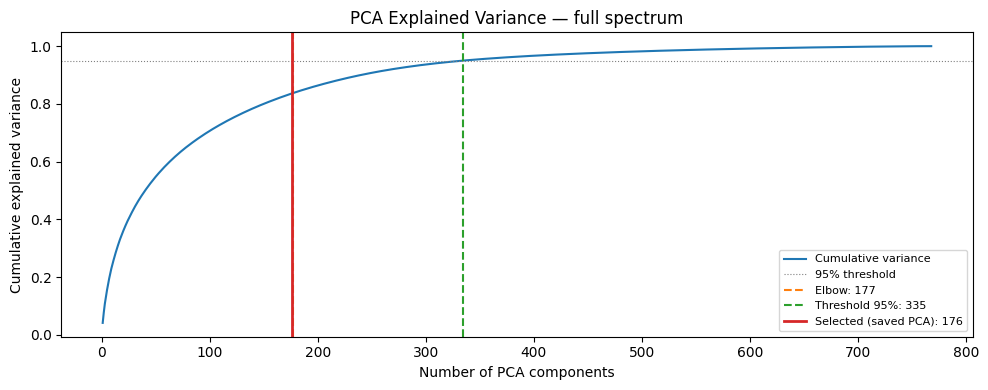

Embedding dim      : 768
Elbow              : 177  (83.74% variance)
Threshold (95%)    : 335  (95.01% variance)
Saved PCA          : 176  (83.61% variance)


In [4]:
from sklearn.decomposition import PCA
from src.embedding.pca import load_pca, select_n_components

pca_path = os.path.join(EMBEDDINGS_ROOT, "_pca", MODEL_SLUG, "shared.pkl")
pca = load_pca(pca_path)
n_selected = pca.n_components_

# Reload the raw embeddings used to fit the shared PCA (all datasets, train split)
emb_parts = []
for ds in DATASETS:
    emb = np.load(os.path.join(EMBEDDINGS_ROOT, ds, MODEL_SLUG, "full.npy"))
    emb_parts.append(emb)
emb_all = np.vstack(emb_parts)

# Full PCA just for visualization (not saved)
max_comp = min(emb_all.shape[0] - 1, emb_all.shape[1])
pca_full = PCA(n_components=max_comp).fit(emb_all)
evr = pca_full.explained_variance_ratio_
cumvar = np.cumsum(evr)

# Recompute elbow/threshold for reference lines
_, ed, td = select_n_components(evr, method="auto", variance_threshold=0.95)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(1, len(cumvar) + 1), cumvar, linewidth=1.5, label="Cumulative variance")
ax.axhline(0.95, color="grey", linestyle=":", linewidth=0.8, label="95% threshold")
ax.axvline(ed,         color="tab:orange", linestyle="--", label=f"Elbow: {ed}")
ax.axvline(td,         color="tab:green",  linestyle="--", label=f"Threshold 95%: {td}")
ax.axvline(n_selected, color="tab:red",    linestyle="-",  linewidth=2,
           label=f"Selected (saved PCA): {n_selected}")
ax.set_xlabel("Number of PCA components")
ax.set_ylabel("Cumulative explained variance")
ax.set_title("PCA Explained Variance — full spectrum")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f"Embedding dim      : {emb_all.shape[1]}")
print(f"Elbow              : {ed}  ({cumvar[ed-1]:.2%} variance)")
print(f"Threshold (95%)    : {td}  ({cumvar[td-1]:.2%} variance)")
print(f"Saved PCA          : {n_selected}  ({cumvar[n_selected-1]:.2%} variance)")


## 3. Embedding Space — 2-D UMAP Projection

Requires `umap-learn` (`pip install umap-learn`).  
We subsample to 5 000 points per dataset to keep it fast.

c:\Users\Alexandre\miniconda3\envs\faiss2\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


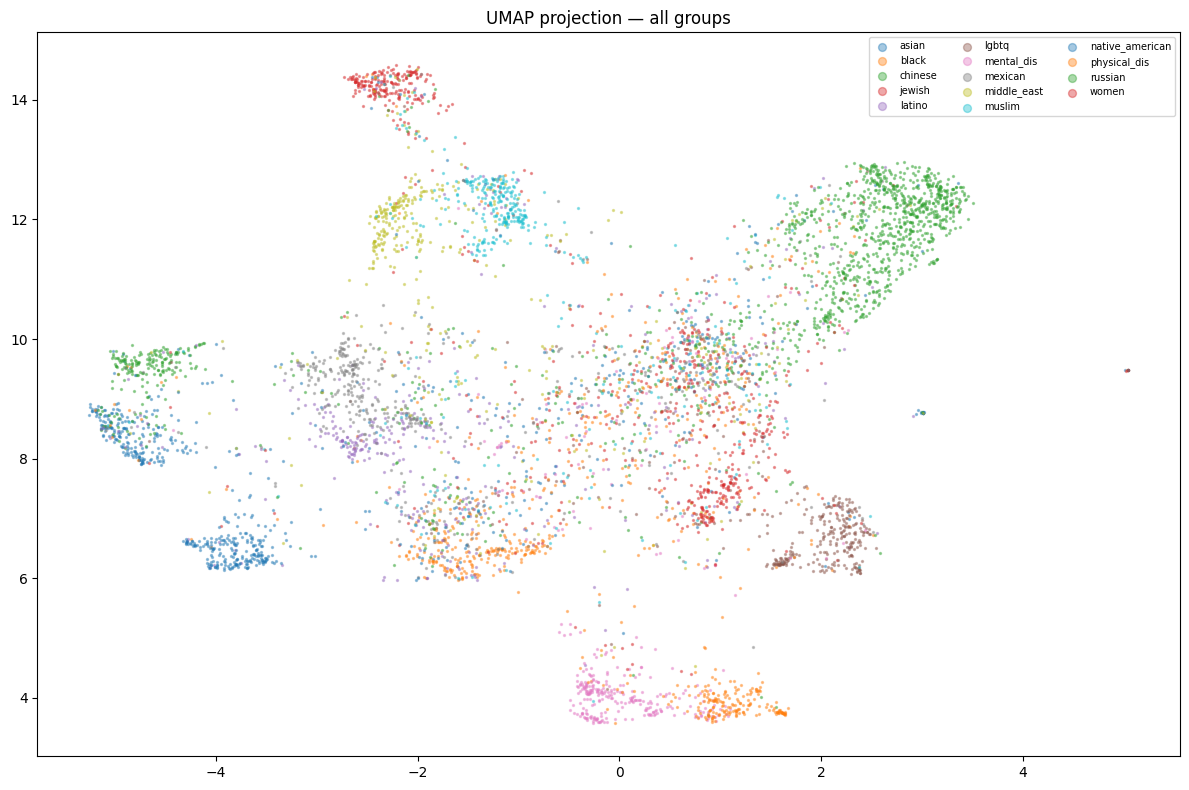

In [5]:
try:
    import umap
    from src.embedding.pca import project

    UMAP_SAMPLE = 5_000
    frames = []
    for ds in DATASETS:
        csv = pd.read_csv(os.path.join(PREPROCESSED_ROOT, ds, "full.csv"))
        emb = np.load(os.path.join(EMBEDDINGS_ROOT, ds, MODEL_SLUG, "full.npy"))
        emb_r = project(pca, emb)
        sample_idx = np.random.choice(len(csv), min(UMAP_SAMPLE, len(csv)), replace=False)
        sub_df = csv.iloc[sample_idx].copy()
        sub_df["_emb"] = list(emb_r[sample_idx])
        frames.append(sub_df)

    df_all = pd.concat(frames, ignore_index=True)
    X = np.stack(df_all["_emb"].values)

    reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=30)
    coords = reducer.fit_transform(X)

    df_all["umap_x"] = coords[:, 0]
    df_all["umap_y"] = coords[:, 1]

    fig, ax = plt.subplots(figsize=(12, 8))
    for grp, sub in df_all.groupby("group"):
        ax.scatter(sub["umap_x"], sub["umap_y"], s=2, alpha=0.4, label=grp)
    ax.legend(markerscale=4, fontsize=7, ncol=3)
    ax.set_title("UMAP projection — all groups")
    plt.tight_layout()
    plt.show()

except ImportError:
    print("umap-learn not installed. Run: pip install umap-learn")

## 4. Density Distributions per Group and K

In [6]:
# Load one CSV per dataset (all K values and PCA/raw in the same file)
density_frames = []
for ds in DATASETS:
    path = os.path.join(EMBEDDINGS_ROOT, ds, MODEL_SLUG, "densities.csv")
    if os.path.exists(path):
        df = pd.read_csv(path)
        df["dataset"] = ds
        density_frames.append(df)

df_combined = pd.concat(density_frames, ignore_index=True)
print(f"Total rows: {len(df_combined):,}")
print("Columns:", df_combined.columns.tolist())

Total rows: 251,944
Columns: ['text', 'group', 'label', 'density_k5_asian', 'density_k5_black', 'density_k5_chinese', 'density_k5_jewish', 'density_k5_latino', 'density_k5_lgbtq', 'density_k5_mental_dis', 'density_k5_mexican', 'density_k5_middle_east', 'density_k5_muslim', 'density_k5_native_american', 'density_k5_physical_dis', 'density_k5_russian', 'density_k5_women', 'density_k5_all', 'density_k5_ratio', 'density_pca_k5_asian', 'density_pca_k5_black', 'density_pca_k5_chinese', 'density_pca_k5_jewish', 'density_pca_k5_latino', 'density_pca_k5_lgbtq', 'density_pca_k5_mental_dis', 'density_pca_k5_mexican', 'density_pca_k5_middle_east', 'density_pca_k5_muslim', 'density_pca_k5_native_american', 'density_pca_k5_physical_dis', 'density_pca_k5_russian', 'density_pca_k5_women', 'density_pca_k5_all', 'density_pca_k5_ratio', 'density_k100_asian', 'density_k100_black', 'density_k100_chinese', 'density_k100_jewish', 'density_k100_latino', 'density_k100_lgbtq', 'density_k100_mental_dis', 'densit

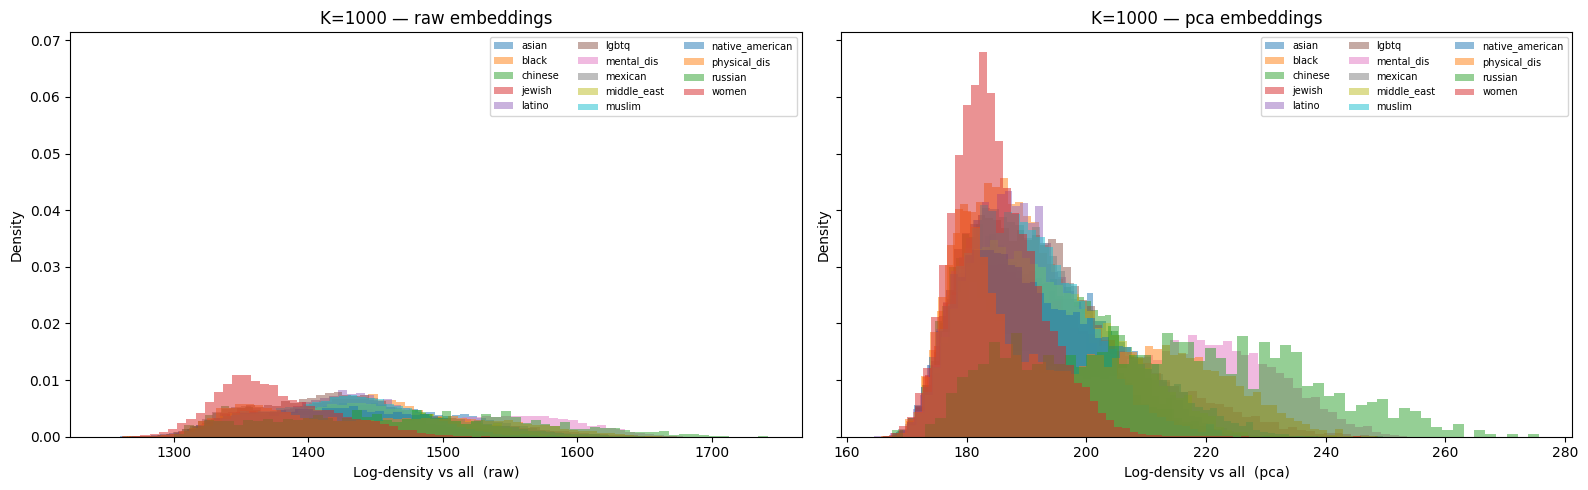

In [7]:
# Distribution of density_all for largest K — raw vs PCA side by side
k_plot = max(K_VALUES)

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
for ax, space in zip(axes, ["raw", "pca"]):
    col = f"density_k{k_plot}_all" if space == "raw" else f"density_pca_k{k_plot}_all"
    if col not in df_combined.columns:
        ax.set_title(f"{space} — column not found")
        continue
    for grp, sub in df_combined.groupby("group"):
        ax.hist(sub[col], bins=60, alpha=0.5, label=grp, density=True)
    ax.set_xlabel(f"Log-density vs all  ({space})")
    ax.set_ylabel("Density")
    ax.set_title(f"K={k_plot} — {space} embeddings")
    ax.legend(fontsize=7, ncol=3)

plt.tight_layout()
plt.show()

## 5. Density Ratio (Russian vs All)

Percentile Values:


,density_k5_ratio,density_pca_k5_ratio,density_k100_ratio,density_pca_k100_ratio,density_k1000_ratio,density_pca_k1000_ratio
0th,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.033720e-40
50th,0.000000e+00,1.699579e-14,1.999225e-40,6.624635e-10,3.521505e-30,4.556297e-07
75th,4.568290e-29,3.283769e-07,1.092534e-18,1.457555e-04,4.021703e-13,3.871079e-03
90th,7.999431e-13,2.922248e-03,9.733759e-08,4.409059e-02,1.581459e-05,1.354063e-01
95th,6.152038e-07,6.052167e-02,2.488675e-04,2.313088e-01,3.057732e-03,3.799666e-01
99th,6.796594e-02,6.330452e-01,1.758666e-01,7.681966e-01,2.563552e-01,8.202677e-01
99.9th,9.997559e-01,9.999847e-01,9.156671e-01,9.910720e-01,9.123317e-01,9.939782e-01
100th,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00


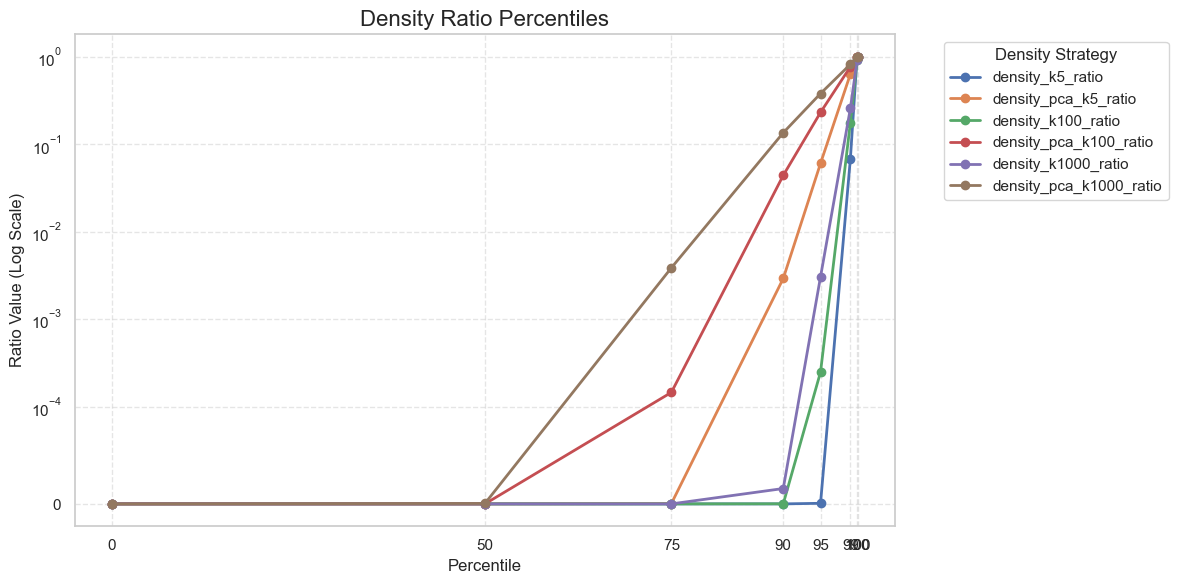

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# 1. Load the data
csv_path = "../outputs/2_embeddings/toxigen/sentence-transformers_all-mpnet-base-v2/densities.csv"
df = pd.read_csv(csv_path)
# Filter only the ratio columns
ratio_cols = [c for c in df.columns if "ratio" in c]
# 2. Calculate the percentiles
percentiles = [0, 50, 75, 90, 95, 99, 99.9, 100]
percentile_data = {}
for col in ratio_cols:
    # We use np.percentile to calculate the exact values at each threshold
    percentile_data[col] = np.percentile(df[col].values, percentiles)
# Create a DataFrame for easy viewing
percentile_df = pd.DataFrame(percentile_data, index=[f"{p}th" for p in percentiles])
print("Percentile Values:")
display(percentile_df)
# 3. Plot the percentiles
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")
# Plot each column's percentiles as a line
for col in ratio_cols:
    plt.plot(percentiles, percentile_data[col], marker='o', label=col, linewidth=2)
plt.title("Density Ratio Percentiles", fontsize=16)
plt.xlabel("Percentile", fontsize=12)
plt.ylabel("Ratio Value (Log Scale)", fontsize=12)
# Use a symlog (symmetrical log) scale because we have exact zeroes
plt.yscale("symlog", linthresh=1e-4) 
plt.xticks(percentiles)
plt.legend(title="Density Strategy", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

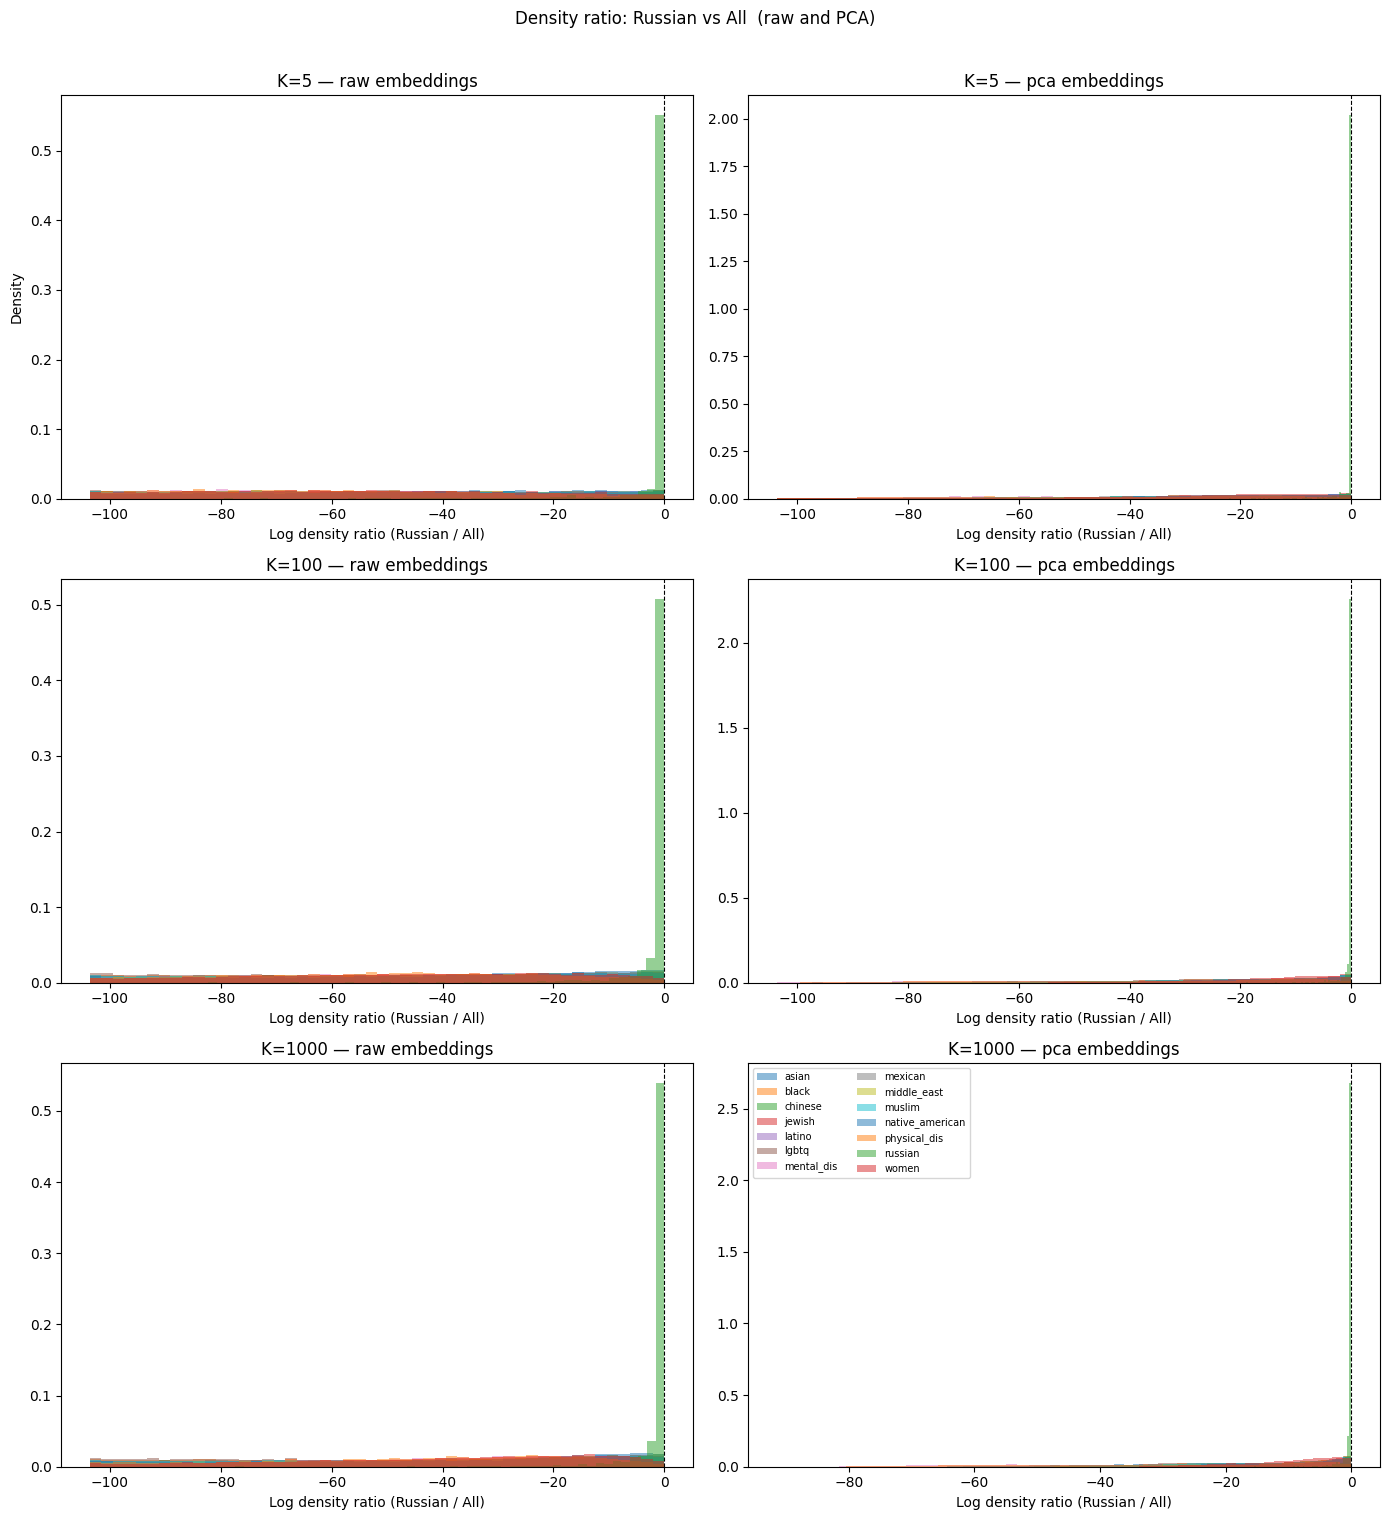

In [8]:
# Density ratio per K and embedding space (raw vs PCA)
n_rows, n_cols = len(K_VALUES), 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows), sharey=False)
if n_rows == 1:
    axes = [axes]

for row, k in enumerate(K_VALUES):
    for col, space in enumerate(["raw", "pca"]):
        ax = axes[row][col]
        ratio_col = f"density_k{k}_ratio" if space == "raw" else f"density_pca_k{k}_ratio"
        if ratio_col not in df_combined.columns:
            ax.set_title(f"K={k} {space} — no ratio column")
            continue
        for grp, sub in df_combined.groupby("group"):
            log_ratio = np.log(sub[ratio_col].replace(0, np.nan).dropna())
            ax.hist(log_ratio, bins=50, alpha=0.5, label=grp, density=True)
        ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
        ax.set_xlabel("Log density ratio (Russian / All)")
        ax.set_title(f"K={k} — {space} embeddings")

axes[0][0].set_ylabel("Density")
axes[-1][-1].legend(fontsize=7, ncol=2)
plt.suptitle("Density ratio: Russian vs All  (raw and PCA)", y=1.01)
plt.tight_layout()
plt.show()

## 6. Cross-Group Density Heatmap

Mean log-density of each group's samples against every other group's reference set.

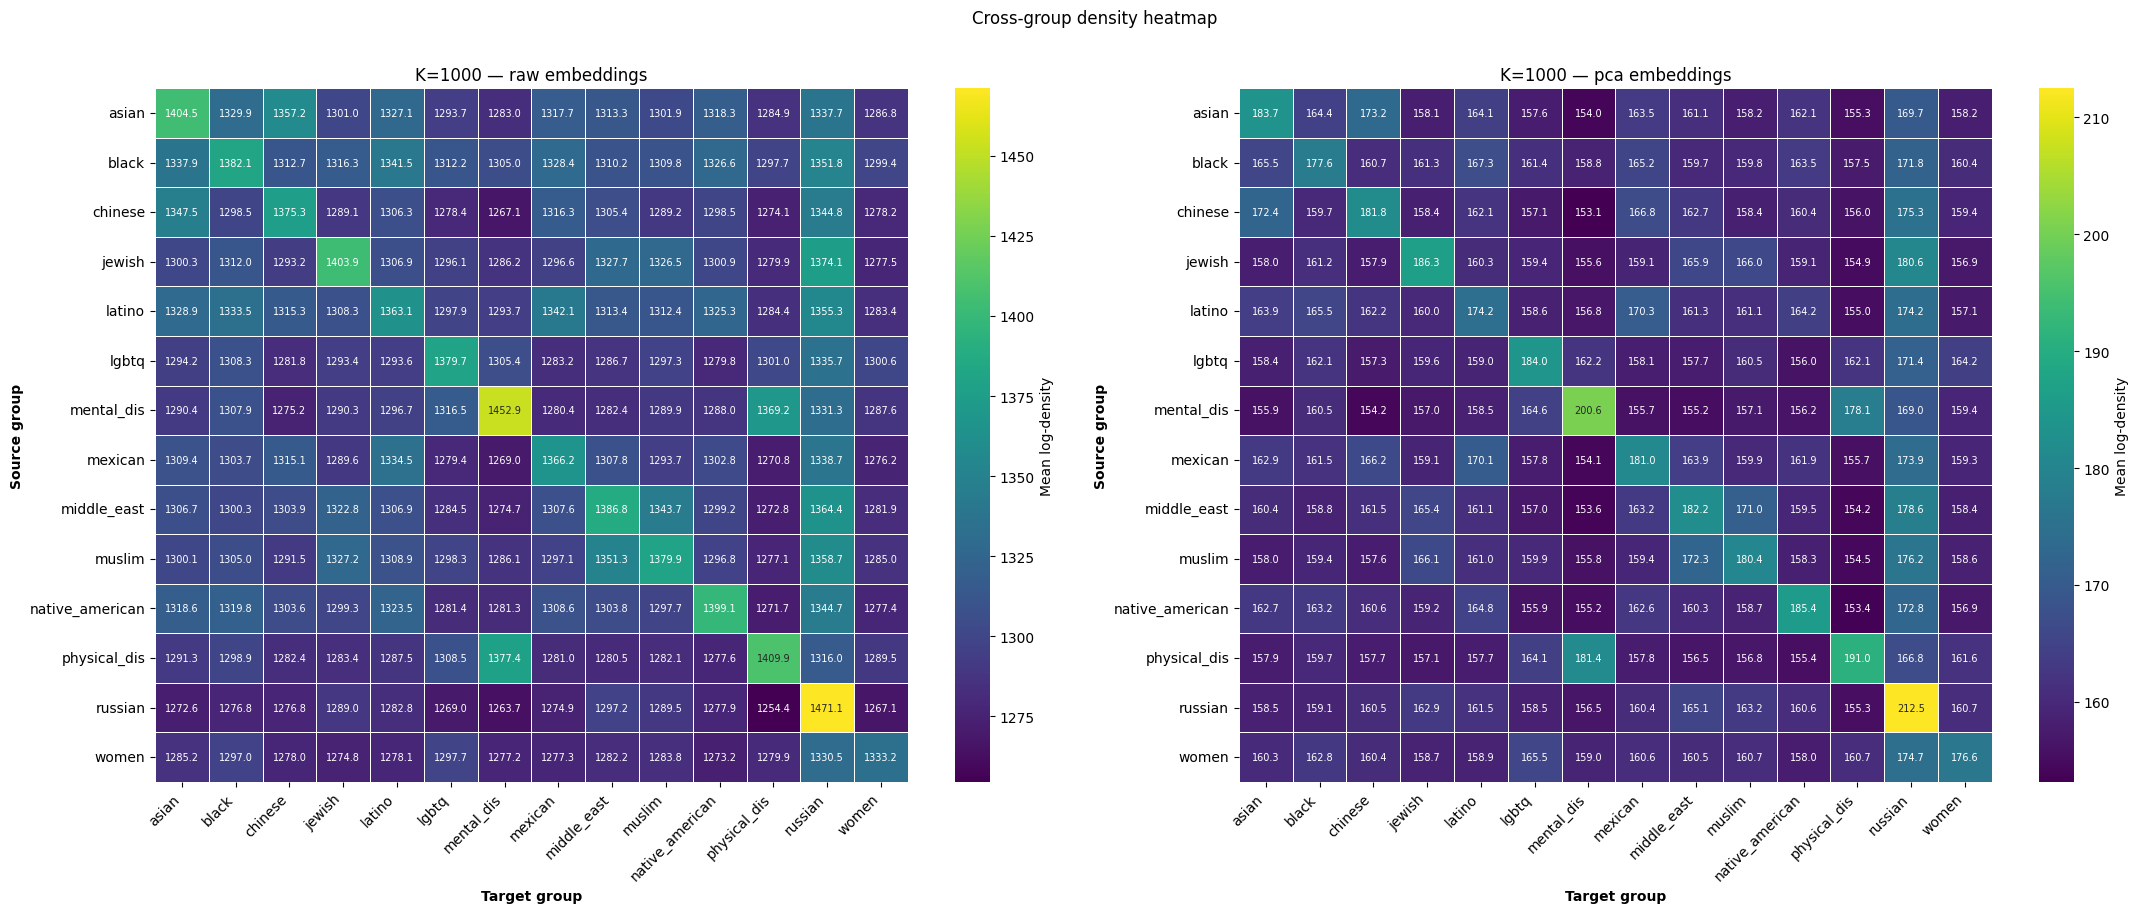

In [9]:
# Cross-group density heatmap — raw and PCA side by side for largest K
k_heat = max(K_VALUES)
groups = sorted(df_combined["group"].unique())

fig, axes = plt.subplots(1, 2, figsize=(22, 9))
for ax, space in zip(axes, ["raw", "pca"]):
    prefix = f"density_k{k_heat}_" if space == "raw" else f"density_pca_k{k_heat}_"
    group_cols = [c for c in df_combined.columns if c.startswith(prefix) and not c.endswith(("_all", "_ratio"))]
    col_labels = [c.replace(prefix, "") for c in group_cols]

    matrix = pd.DataFrame(index=groups, columns=col_labels, dtype=float)
    for grp in groups:
        sub = df_combined[df_combined["group"] == grp]
        for col, lbl in zip(group_cols, col_labels):
            if col in sub.columns:
                matrix.loc[grp, lbl] = sub[col].mean()

    sns.heatmap(
        matrix.astype(float), ax=ax,
        annot=True, fmt=".1f", cmap="viridis",
        linewidths=0.5, annot_kws={"size": 7},
        cbar_kws={"label": "Mean log-density"},
    )
    ax.set_xlabel("Target group", fontweight="bold")
    ax.set_ylabel("Source group", fontweight="bold")
    ax.set_title(f"K={k_heat} — {space} embeddings")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

plt.suptitle("Cross-group density heatmap", y=1.01)
plt.tight_layout()
plt.show()